**Neural networks for road segmentation**
========================

Your next task is to train neural network to segment road on images from car cams.

The original dataset is provided by Karlsruhe Institute of Technology (http://www.cvlibs.net/datasets/kitti/eval_road.php). Their images are ±370x1270, but, for simlictiy, we will use 370x370 squares.

One can download the dataset from https://disk.yandex.ru/d/QPOw4hk84-se_w

Here is an example of input data with corresponding ground truth:

In [1]:
!pip3 install torch
!pip3 install numpy
!pip3 install opencv-python
!pip3 install torchvision
!pip3 install matplotlib
!pip3 install tqdm
!pip3 install albumentations
!pip3 install --upgrade ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import json, urllib.parse, urllib.request
public_key = 'https://disk.yandex.ru/d/QPOw4hk84-se_w'
params = urllib.parse.urlencode({'public_key': public_key})
url = f'https://cloud-api.yandex.net/v1/disk/public/resources/download?{params}'
with urllib.request.urlopen(url) as resp:
    data = json.loads(resp.read().decode('utf-8'))
print(data['href'])

https://downloader.disk.yandex.ru/disk/cfd38dfa83b9eeecda58fa9373a8d6f1850631aff9dc662bad52a45872b3d54f/69223046/_gIe7sqhiKGWvpES7oGEV4LBmE3mWZFnEs8QSgwfnop2zSm1XUdSGhsGQNyfSRay16J6z6P2MFmGUJp4elnHUA%3D%3D?uid=0&filename=data.zip&disposition=attachment&hash=Xsh98wiJiWn2t1I0wKL9nchDkGZQSAbOJ6BZci%2B3foEw4jU1THxu4mw5xq7jkf78q/J6bpmRyOJonT3VoXnDag%3D%3D%3A&limit=0&content_type=application%2Fzip&owner_uid=598766231&fsize=207633511&hid=7cc0185851525118e8abc1a575879e9f&media_type=compressed&tknv=v3


In [3]:
import os
if not os.path.isdir("data"):
    !curl -L -o data.zip data['href']
    !unzip -q data.zip
else:
    print("Data folder already exists, skipping download.")

Data folder already exists, skipping download.


In [4]:
import os
import cv2
import numpy as np

import torchvision.transforms as transforms
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
def get_paths(path):
    _, _, filenames = next(os.walk(path))

    images_paths = []
    for filename in sorted(filenames):            
        images_paths.append(os.path.join(path, filename))
    
    return np.stack(images_paths)

class RoadDataset(Dataset):
    """Feel free to rewrite it. For ex. cache all images in RAM to increase training speed"""
    def __init__(self, images, masks, transform, aug=None, mask_transform=None):
        self.images = sorted(images)
        self.masks = sorted(masks)
        self.transform = transform
        self.mask_transform = mask_transform if mask_transform is not None else transforms.ToTensor()
        self.aug = aug
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):        
        im_name = self.images[idx]
        mask_name = self.masks[idx]
        
        image = cv2.imread(im_name)[:,:,::-1].astype(np.float32) / 255.0  # ::-1 to convert from BGR to RGB
        mask = cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)
        
        if self.aug:
            sample = self.aug(
                image=image,
                mask=mask,
            )
        else:
            sample = {
                'image': image,
                'mask': mask,
            }
        
        sample['image'] = self.transform(sample['image']).float()
        sample['mask'] = self.mask_transform(sample['mask']).float()

        return sample


In [6]:
X_train = get_paths("data/train/images")
y_train = get_paths("data/train/gt")

transform = transforms.Compose([
    transforms.ToTensor(),
])

In [7]:
train_dataset = RoadDataset(X_train, y_train, transform)

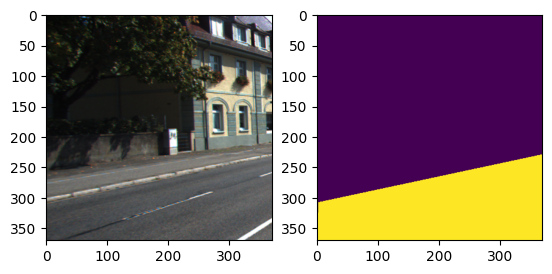

In [8]:
sample = train_dataset[110]
image = sample['image']
mask = sample['mask']

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0))

Workflow:
---
* Choose correct loss function, write training loop and code for testing. Feel free to use previous HW for inspiration. 
* Train any segmentation neural network from scratch (for example U-Net) and achieve >= 0.75 IoU on test set (40% points). See function to calculate the metric below.
* Use any pretrained model for image classification, convert it for segmentation by adding decoder (don't forget skip-connections) or usign dilated convolutions and achieve >= 0.87 IoU  on test set (60% points).

You're not allowed to do only one thing: train your network on test set.

----
Your final solution will consist of an ipython notebook with code (for final networks training + any experiments with data) and test metric calculation.

Feel free to ask in Telegram chat if something is not clear :3


In [9]:
print(f"Dataset length {len(train_dataset)}")

Dataset length 648


Dataset is small so actively use data augmentation: rotations, flip, color-change etc. to prevent overfitting.

Most likely you'll have to pad your images to 512x512 (it divides by 2^5=32, like U-Net wants). Use PadIfNeeded from Albumentations and central crop (see below) after prediction to calculate loss/metrics (you don't want to pay attention on padded values).

----
There is a hard data class imbalance in dataset, so the network output will be biased toward "zero" class. You can either tune the minimal probability threshold for the "road" class, or add class weights in optimized loss. You also can try to use softIoU or DICE loss.

Good luck!

In [10]:
def calc_iou(prediction, ground_truth):
    n_images = len(prediction)
    intersection, union = 0, 0
    for i in range(n_images):
        intersection += np.logical_and(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum() 
        union += np.logical_or(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
    return float(intersection) / union

In [11]:
def central_crop(images, size):
    current_size = images.size(2)
    border_len = (current_size - size) // 2
    return images[:, :, border_len:current_size-border_len, border_len:current_size-border_len] # why in original notebook it wasn't returning this value???

In [12]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import albumentations as A
import random
from functools import partial
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# for reproducibility let us fix the seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using device: {DEVICE}")

# progress bars flood IOPub in notebooks, so disable them unless SHOW_PROGRESS=1
PROGRESS = os.getenv("SHOW_PROGRESS", "0") == "1"
tqdm_progress = partial(
    tqdm,
    leave=False,
    mininterval=1.0,
    miniters=10,
    disable=not PROGRESS,
    )


Using device: cuda


### Training/validation/test preparation

In [13]:
ORIGINAL_IMAGE_SIZE = 370
UNET_DOWN_BLOCKS = 5
pad_multiple = 2 ** UNET_DOWN_BLOCKS
PADDED_SIZE = max(512, int(np.ceil(ORIGINAL_IMAGE_SIZE / pad_multiple) * pad_multiple))
VAL_RATIO = 0.15

print("pad inputs to " + str(PADDED_SIZE))

# here we do so called "spaghetti augmentation"
# it was derived after a lot of (11) experiments with different augmentations
# each time after diving deep into the ablations docs, the new one was added
# if there is a better way to do it, please let me know
train_aug = A.Compose([
    A.PadIfNeeded(min_height=PADDED_SIZE, min_width=PADDED_SIZE, border_mode=cv2.BORDER_REFLECT_101),
    A.RandomResizedCrop(size=(PADDED_SIZE, PADDED_SIZE), scale=(0.85, 1.0), ratio=(0.95, 1.05), p=0.25),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=12, border_mode=cv2.BORDER_REFLECT_101, p=0.3),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(-0.05, 0.05),
        rotate=(-10, 10),
        shear=(-3, 3),
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.35,
    ),
    A.OneOf([
        A.ElasticTransform(alpha=25, sigma=5),
        A.GridDistortion(num_steps=4, distort_limit=0.2),
    ], p=0.2),
    A.OneOf([
        A.MotionBlur(blur_limit=3),
        A.MedianBlur(blur_limit=3),
        A.GaussianBlur(blur_limit=3),
        A.GaussNoise(p=0.25),
    ], p=0.25),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05, p=0.3),
    A.RandomBrightnessContrast(p=0.25),
    A.HueSaturationValue(p=0.2),
    A.CoarseDropout(
        num_holes_range=(1, 3),
        hole_height_range=(12, 24),
        hole_width_range=(12, 24),
        fill=0,
        fill_mask=0,
        p=0.2,
    ),
])

val_aug = A.Compose([
    A.PadIfNeeded(min_height=PADDED_SIZE, min_width=PADDED_SIZE, border_mode=cv2.BORDER_REFLECT_101)
])

test_aug = val_aug

num_samples = len(X_train)
val_count = max(1, int(num_samples * VAL_RATIO))
perm = np.random.RandomState(SEED).permutation(num_samples)
val_idx = perm[:val_count]
train_idx = perm[val_count:]

train_dataset = RoadDataset(X_train[train_idx], y_train[train_idx], transform, aug=train_aug)
val_dataset = RoadDataset(X_train[val_idx], y_train[val_idx], transform, aug=val_aug)

X_test = get_paths("data/test/images")
y_test = get_paths("data/test/gt")
test_dataset = RoadDataset(X_test, y_test, transform, aug=test_aug)

BATCH_SIZE = 1
NUM_WORKERS = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train/Val/Test sizes: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}")

pad inputs to 512
Train/Val/Test sizes: 551/97/219


### U-Net model

In [14]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, gn_groups=8):
        super().__init__()

        def norm_layer(num_channels):
            groups = min(gn_groups, num_channels)
            while groups > 1 and num_channels % groups != 0:
                groups -= 1
            return nn.GroupNorm(groups, num_channels)

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            norm_layer(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            norm_layer(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)
        if diff_y != 0 or diff_x != 0:
            x1 = F.pad(x1, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=64, depth=5):
        super().__init__()
        encoder_channels = [base_channels * (2 ** i) for i in range(depth + 1)]
        self.inc = DoubleConv(in_channels, encoder_channels[0])
        self.downs = nn.ModuleList(
            [Down(encoder_channels[i], encoder_channels[i + 1]) for i in range(depth)]
        )
        bottleneck_channels = encoder_channels[-1]
        self.bottleneck = DoubleConv(bottleneck_channels, bottleneck_channels * 2)
        decoder_in = bottleneck_channels * 2
        self.ups = nn.ModuleList()
        for skip_channels in reversed(encoder_channels):
            self.ups.append(Up(decoder_in + skip_channels, skip_channels))
            decoder_in = skip_channels
        self.outc = OutConv(encoder_channels[0], out_channels)

    def forward(self, x):
        skips = []
        x = self.inc(x)
        skips.append(x)
        for down in self.downs:
            x = down(x)
            skips.append(x)
        x = self.bottleneck(x)
        for up, skip in zip(self.ups, reversed(skips)):
            x = up(x, skip)
        return self.outc(x)


model = UNet().to(DEVICE)
print(f"Model params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

Model params: 503.28M


### Loss, metrics, and helpers

In [16]:
import contextlib

pos_weight_value = 3.0
bce_loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], device=DEVICE))

def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    numerator = 2 * (probs * targets).sum(dim=(2, 3))
    denominator = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + eps
    dice = 1 - (numerator / denominator)
    return dice.mean()


def segmentation_loss(logits, targets, dice_weight=0.5):
    bce = bce_loss_fn(logits, targets)
    dice = dice_loss(logits, targets)
    return bce + dice_weight * dice, bce.detach(), dice.detach()


def batch_to_device(batch):
    return batch['image'].to(DEVICE), batch['mask'].to(DEVICE)


def compute_iou_from_loader(model, loader, threshold=0.5, crop_size=ORIGINAL_IMAGE_SIZE):
    model.eval()
    preds, targets = [], []
    iterator = tqdm_progress(loader, desc="IoU eval")
    use_cuda = torch.cuda.is_available()
    with torch.inference_mode():
        for batch in iterator:
            images, masks = batch_to_device(batch)
            if use_cuda:
                autocast_ctx = torch.amp.autocast(device_type="cuda")
            else:
                autocast_ctx = contextlib.nullcontext()
            with autocast_ctx:
                logits = model(images)
                probs = torch.sigmoid(logits)
            if crop_size:
                probs = central_crop(probs, crop_size)
                masks = central_crop(masks, crop_size)
            preds.extend((probs > threshold).float().cpu().numpy().squeeze(1))
            targets.extend(masks.cpu().numpy().squeeze(1))
    return calc_iou(preds, targets)

### Training loop

In [15]:
import contextlib


def run_epoch(model, loader, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = total_bce = total_dice = 0.0
    use_cuda = torch.cuda.is_available()
    use_scaler = scaler is not None and use_cuda
    phase = "train" if is_train else "val"
    iterator = tqdm_progress(loader, desc=f"{phase.capitalize()} epoch")

    for batch in iterator:
        images, masks = batch_to_device(batch)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        autocast_context = torch.amp.autocast(device_type="cuda") if use_cuda else contextlib.nullcontext()
        with autocast_context:
            loss, bce, dice = segmentation_loss(model(images), masks)
        if is_train:
            if use_scaler:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
        total_loss += loss.item()
        total_bce += bce.item()
        total_dice += dice.item()
        iterator.set_postfix({"loss": f"{loss.item():.3f}"})

    num_batches = len(loader)
    return (
        total_loss / num_batches,
        total_bce / num_batches,
        total_dice / num_batches,
    )


def fit(model, train_loader, val_loader, epochs=25, lr=1e-4, weight_decay=1e-4, save_path="checkpoints/unet_road.pth"):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler(device="cuda", enabled=torch.cuda.is_available())
    history = {"train": [], "val": []}
    best_iou = 0.0

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch:02d}/{epochs}")
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer, scaler=scaler)
        val_metrics = run_epoch(model, val_loader)
        val_iou = compute_iou_from_loader(model, val_loader)
        history["train"].append(train_metrics)
        history["val"].append(val_metrics + (val_iou,))

        print(f"train_loss={train_metrics[0]:.4f} | val_loss={val_metrics[0]:.4f} | val_iou={val_iou:.4f}")

        # saving checkpoint, so in the end of the training we can load the best model
        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), save_path)
            print(f"new best IoU, checkpoint saved to {save_path}")

    return history, best_iou


### Launch training

In [17]:
NUM_EPOCHS = 50
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
CHECKPOINT_PATH = "checkpoints/unet_road.pth"

history, best_val_iou = fit(
    model,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    save_path=CHECKPOINT_PATH,
)
print(f"best val IoU: {best_val_iou:.4f}")


Epoch 01/50
train_loss=0.8600 | val_loss=0.6534 | val_iou=0.6306
new best IoU, checkpoint saved to checkpoints/unet_road.pth
Epoch 02/50
train_loss=0.6098 | val_loss=0.5311 | val_iou=0.6387
new best IoU, checkpoint saved to checkpoints/unet_road.pth
Epoch 03/50
train_loss=0.5650 | val_loss=0.5143 | val_iou=0.6752
new best IoU, checkpoint saved to checkpoints/unet_road.pth
Epoch 04/50
train_loss=0.5254 | val_loss=0.4770 | val_iou=0.6890
new best IoU, checkpoint saved to checkpoints/unet_road.pth
Epoch 05/50
train_loss=0.5247 | val_loss=0.4559 | val_iou=0.6987
new best IoU, checkpoint saved to checkpoints/unet_road.pth
Epoch 06/50
train_loss=0.5158 | val_loss=0.4492 | val_iou=0.7132
new best IoU, checkpoint saved to checkpoints/unet_road.pth
Epoch 07/50
train_loss=0.4884 | val_loss=0.4317 | val_iou=0.7278
new best IoU, checkpoint saved to checkpoints/unet_road.pth
Epoch 08/50
train_loss=0.4810 | val_loss=0.4470 | val_iou=0.7008
Epoch 09/50
train_loss=0.4722 | val_loss=0.4350 | val_iou=0.

### Testing and qualitative checks

In [18]:
THRESHOLD = 0.45
CROP_SIZE = ORIGINAL_IMAGE_SIZE

if os.path.exists(CHECKPOINT_PATH):
    state_dict = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(state_dict)
    print(f"loaded checkpoint from {CHECKPOINT_PATH}")
else:
    print("checkpoint not found, use current RAM weights")

test_iou = compute_iou_from_loader(model, test_loader, threshold=THRESHOLD, crop_size=CROP_SIZE)
print(f"test IoU @ threshold={THRESHOLD:.2f}: {test_iou:.4f}")

loaded checkpoint from checkpoints/unet_road.pth
test IoU @ threshold=0.45: 0.7539


In [23]:
def visualize_predictions(model, loader, num_samples=3, threshold=THRESHOLD, crop_size=CROP_SIZE):
    model.eval()
    shown = 0
    with torch.no_grad():
        for batch in loader:
            images, masks = batch_to_device(batch)
            logits = model(images)
            probs = torch.sigmoid(logits)
            if crop_size:
                images = central_crop(images, crop_size)
                masks = central_crop(masks, crop_size)
                probs = central_crop(probs, crop_size)
            for idx in range(images.size(0)):
                if shown >= num_samples:
                    return
                image_np = images[idx].cpu().permute(1, 2, 0).numpy()
                mask_np = masks[idx].cpu().squeeze(0).numpy()
                pred_np = (probs[idx] > threshold).float().cpu().squeeze(0).numpy()

                plt.figure(figsize=(12, 4))
                plt.subplot(1, 3, 1)
                plt.imshow(image_np)
                plt.title('Image')
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.imshow(mask_np, cmap='gray')
                plt.title('Ground truth')
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.imshow(pred_np, cmap='gray')
                plt.title('Prediction')
                plt.axis('off')

                plt.show()
                shown += 1

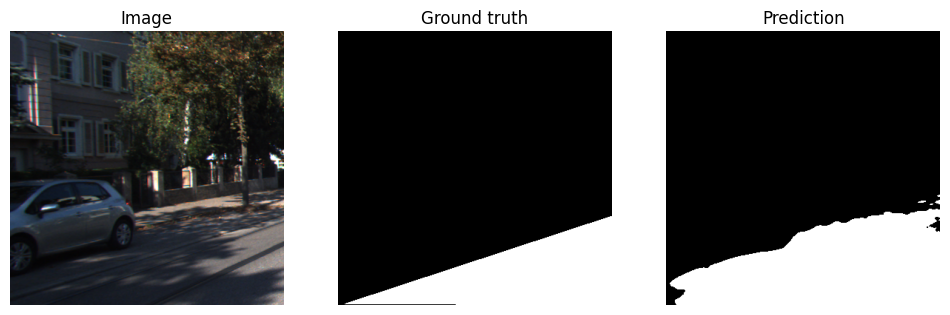

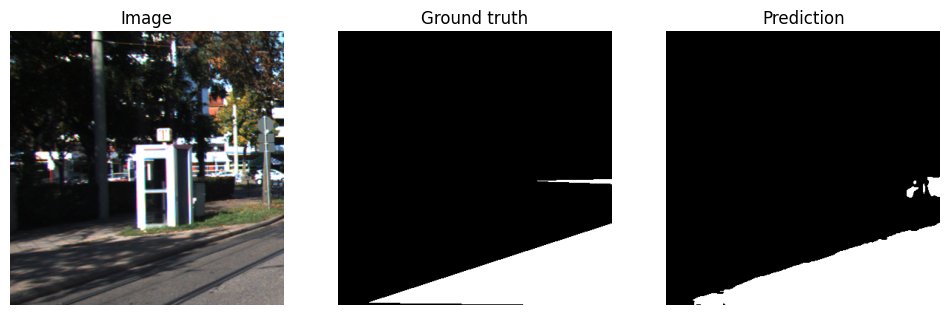

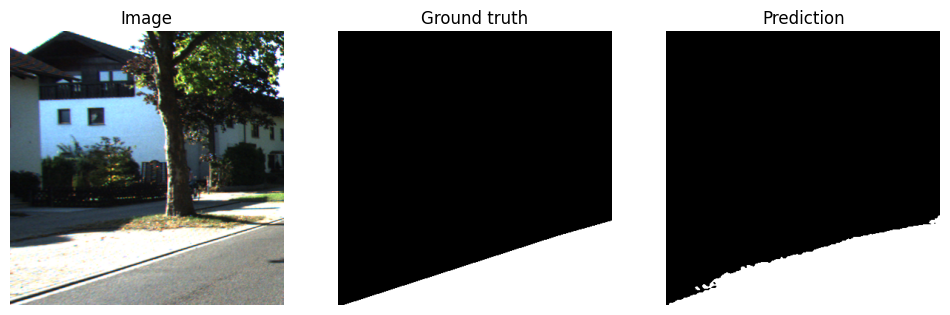

In [ ]:

visualize_predictions(model, test_loader)


### pre-trained model


In [17]:
from torchvision.models import resnet34

class ResNet34UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        try:
            from torchvision.models import ResNet34_Weights
            encoder = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
        except Exception:
            encoder = resnet34(pretrained=True)
        self.conv1 = encoder.conv1
        self.bn1 = encoder.bn1
        self.relu = encoder.relu
        self.maxpool = encoder.maxpool
        self.layer1 = encoder.layer1
        self.layer2 = encoder.layer2
        self.layer3 = encoder.layer3
        self.layer4 = encoder.layer4
        self.center = DoubleConv(512, 1024)
        self.up4 = Up(1024 + 256, 256)
        self.up3 = Up(256 + 128, 128)
        self.up2 = Up(128 + 64, 64)
        self.up1 = Up(64 + 64, 64)
        self.outc = OutConv(64, out_channels)

    def forward(self, x):
        input_spatial = x.shape[2:]
        x0 = self.relu(self.bn1(self.conv1(x)))
        x1 = self.maxpool(x0)
        x2 = self.layer1(x1)
        x3 = self.layer2(x2)
        x4 = self.layer3(x3)
        x5 = self.layer4(x4)
        x_center = self.center(x5)
        x = self.up4(x_center, x4)
        x = self.up3(x, x3)
        x = self.up2(x, x2)
        x = self.up1(x, x0)
        x = self.outc(x)
        x = F.interpolate(x, size=input_spatial, mode="bilinear", align_corners=False)
        return x


In [20]:
PRETRAINED_CHECKPOINT_PATH = "checkpoints/resnet34_unet_road.pth"
PRETRAINED_EPOCHS = 50
PRETRAINED_LR = 3e-4
PRETRAINED_WEIGHT_DECAY = 1e-4

pretrained_model = ResNet34UNet().to(DEVICE)

history_pretrained, best_val_iou_pretrained = fit(
    pretrained_model,
    train_loader,
    val_loader,
    epochs=PRETRAINED_EPOCHS,
    lr=PRETRAINED_LR,
    weight_decay=PRETRAINED_WEIGHT_DECAY,
    save_path=PRETRAINED_CHECKPOINT_PATH,
)

print(f"best val IoU (ResNet34UNet): {best_val_iou_pretrained:.4f}")


Epoch 01/50
train_loss=0.6150 | val_loss=0.5038 | val_iou=0.6831
new best IoU, checkpoint saved to checkpoints/resnet34_unet_road.pth
Epoch 02/50
train_loss=0.4850 | val_loss=0.4741 | val_iou=0.7319
new best IoU, checkpoint saved to checkpoints/resnet34_unet_road.pth
Epoch 03/50
train_loss=0.4260 | val_loss=0.5067 | val_iou=0.7405
new best IoU, checkpoint saved to checkpoints/resnet34_unet_road.pth
Epoch 04/50
train_loss=0.3966 | val_loss=0.3517 | val_iou=0.7626
new best IoU, checkpoint saved to checkpoints/resnet34_unet_road.pth
Epoch 05/50
train_loss=0.3744 | val_loss=0.3927 | val_iou=0.7630
new best IoU, checkpoint saved to checkpoints/resnet34_unet_road.pth
Epoch 06/50
train_loss=0.3316 | val_loss=0.3580 | val_iou=0.7858
new best IoU, checkpoint saved to checkpoints/resnet34_unet_road.pth
Epoch 07/50
train_loss=0.3173 | val_loss=0.3621 | val_iou=0.7826
Epoch 08/50
train_loss=0.2972 | val_loss=0.5349 | val_iou=0.7748
Epoch 09/50
train_loss=0.3099 | val_loss=0.3898 | val_iou=0.7805
E

In [30]:
THRESHOLD = 0.45
CROP_SIZE = ORIGINAL_IMAGE_SIZE

pretrained_model = ResNet34UNet().to(DEVICE)
state_dict = torch.load(PRETRAINED_CHECKPOINT_PATH, map_location=DEVICE)
pretrained_model.load_state_dict(state_dict)

test_iou_pretrained = compute_iou_from_loader(
    pretrained_model,
    test_loader,
    threshold=THRESHOLD,
    crop_size=CROP_SIZE,
)

print(f"test IoU (ResNet34UNet) @ threshold={THRESHOLD:.2f}: {test_iou_pretrained:.4f}")


test IoU (ResNet34UNet) @ threshold=0.45: 0.8592


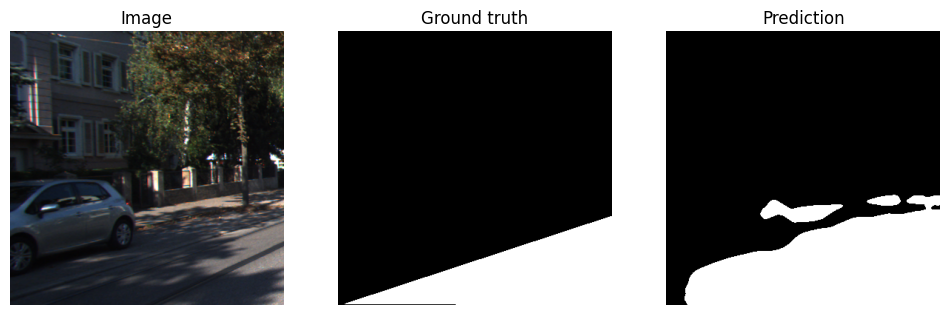

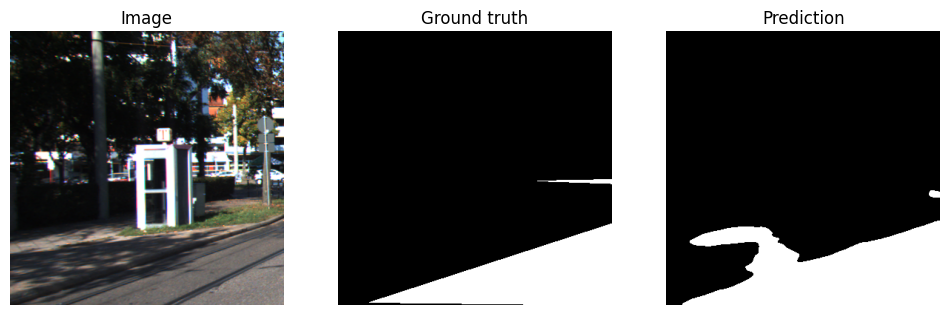

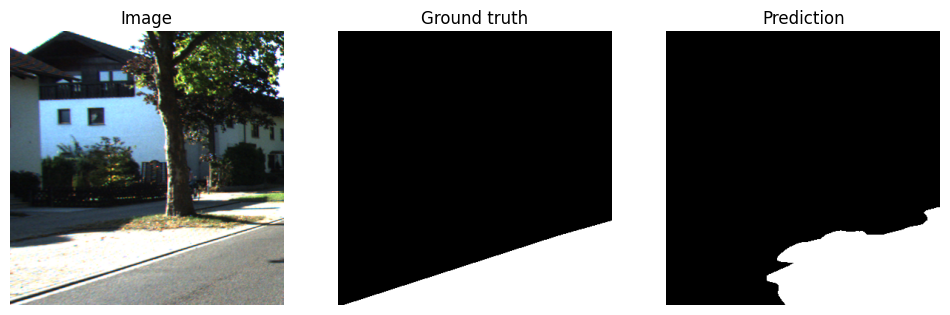

In [31]:
visualize_predictions(pretrained_model, test_loader)